# 01 · Hamiltonian Neural Network (Greydanus, Dzamba & Yosinski, 2019)

Paper: `papers/01_Fundamentos_y_Arquitecturas_Base/Greydanus et al 2019 -
Hamiltonian Neural Networks.pdf` — arXiv:1906.01563, NeurIPS 2019.

**Core idea of the paper (Sec. 2).** Instead of training a network to output the
vector field `(q_dot, p_dot)` directly (notebook `00`), train a network `H_theta(q,
p)` that outputs a single **scalar** — interpreted as the system's total energy —
and obtain the vector field *analytically* from it via **Hamilton's equations**:

$$\dot q = \frac{\partial H_\theta}{\partial p}, \qquad
  \dot p = -\frac{\partial H_\theta}{\partial q}$$

In PyTorch this means: run `H_theta` forward, then call `torch.autograd.grad` on the
*output* with respect to the *input* to get `(dH/dq, dH/dp)`, then swap and negate
one component. Crucially, gradients must be computed with `create_graph=True` so
that the training loss can itself be back-propagated *through* this
differentiation step (a second-order-style use of autograd — this is the one
implementation detail that most trips people up when reproducing this paper).

**Why this should conserve energy.** By construction, the vector field
`(dH/dp, -dH/dq)` is always *tangent to the level sets of H* (this is a standard
fact from Hamiltonian mechanics: `dH/dt = (dH/dq)(dq/dt) + (dH/dp)(dp/dt) =
(dH/dq)(dH/dp) - (dH/dp)(dH/dq) = 0`). So whatever scalar function the network
converges to, *its own* energy is conserved along the flow it generates — even if
that learned function isn't a perfect match to the true physical Hamiltonian. This
is the entire mechanism behind the paper's headline empirical result.

**What this notebook reproduces from the paper:** Fig. 1 (mass-spring / pendulum
comparison against a baseline NN) and Sec. 4.1 (pendulum experiment), using exactly
the same training data, optimizer budget and integrator as notebook `00`, per the
matched-integrator protocol described in section 7.1 of the state-of-the-art
document.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

FRAMEWORK_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(FRAMEWORK_ROOT))
from common import systems, metrics, models  # noqa: E402

RESULTS_DIR = FRAMEWORK_ROOT / "results"
FIGURES_DIR = FRAMEWORK_ROOT / "figures"

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

## Step 1 — Same training data as the baseline (notebook `00`)

Identical seed, identical `(state, derivative)` pairs. This is what makes the
eventual energy-drift comparison a fair, "matched" evaluation rather than an
apples-to-oranges one.

In [2]:
train_state, train_deriv = systems.sample_pendulum_dataset(n_points=2000, seed=SEED)
train_state_t = torch.tensor(train_state, requires_grad=True)
train_deriv_t = torch.tensor(train_deriv)

## Step 2 — The Hamiltonian Neural Network module

`self.H` is a scalar-output MLP (same hidden width/depth as the baseline in
notebook `00`, so the two models are parameter-matched almost exactly — the HNN has
one fewer output unit in its last layer, hence marginally fewer parameters).
`time_derivative` implements Hamilton's equations via autograd, which is the one
piece of "physics" this whole architecture is built around.

In [3]:
class HNN(nn.Module):
    def __init__(self, hidden_dim=200):
        super().__init__()
        self.H = models.MLP(in_dim=2, hidden_dim=hidden_dim, out_dim=1, n_hidden_layers=2)

    def forward(self, state):
        return self.H(state)

    def time_derivative(self, state):
        """Returns (q_dot, p_dot) = (dH/dp, -dH/dq), following Hamilton's equations
        (Greydanus et al., 2019, Eq. 4). `create_graph=True` keeps this operation
        differentiable so the *training* loss can backprop through it."""
        H = self.H(state).sum()  # sum() so grad() below returns per-sample gradients
        dH = torch.autograd.grad(H, state, create_graph=True)[0]
        dHdq, dHdp = dH[:, 0:1], dH[:, 1:2]
        q_dot = dHdp
        p_dot = -dHdq
        return torch.cat([q_dot, p_dot], dim=-1)


hnn = HNN(hidden_dim=200)
print("HNN parameter count:", models.count_parameters(hnn))

HNN parameter count: 41001


## Step 3 — Train: same loss, same optimizer budget as the baseline

`MSE(hnn.time_derivative(q, p), (q_dot_true, p_dot_true))`. Note we still regress a
*derivative* target, exactly like the baseline — the only change is *how* that
prediction is produced internally.

In [4]:
optimizer = torch.optim.Adam(hnn.parameters(), lr=1e-3)
n_epochs = 2000
losses = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = hnn.time_derivative(train_state_t)
    loss = ((pred - train_deriv_t) ** 2).mean()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 400 == 0:
        print(f"epoch {epoch:4d}  train MSE = {loss.item():.3e}")

print(f"final train MSE = {losses[-1]:.3e}")

epoch    0  train MSE = 9.040e-01


epoch  400  train MSE = 1.938e-03


epoch  800  train MSE = 5.362e-05


epoch 1200  train MSE = 1.012e-05


epoch 1600  train MSE = 4.069e-04


final train MSE = 3.328e-06


## Step 4 — Roll out and check energy conservation

Same initial condition, same RK4 integrator, same rollout horizon as notebook `00`
— the only variable being compared is the architecture.

In [5]:
def hnn_vector_field(state, **kwargs):
    s = torch.tensor(state, dtype=torch.float32, requires_grad=True).unsqueeze(0)
    return hnn.time_derivative(s).detach().squeeze(0).numpy()


q0, p0 = 1.6, 0.0
state0 = np.array([q0, p0])
T_SPAN, DT = 20.0, 0.05

true_traj = systems.integrate(systems.pendulum_dynamics, state0, T_SPAN, DT)
pred_traj = systems.integrate(hnn_vector_field, state0, T_SPAN, DT)

H_true, _, _ = metrics.energy_drift(true_traj, systems.pendulum_hamiltonian)
H_pred, abs_drift, rel_drift = metrics.energy_drift(pred_traj, systems.pendulum_hamiltonian)
traj_mse = metrics.trajectory_mse(pred_traj, true_traj)

print(f"trajectory MSE over rollout: {traj_mse:.4e}")
print(f"max |energy drift|:          {abs_drift.max():.4e}")
print(f"max relative energy drift:   {rel_drift.max():.4e}")

trajectory MSE over rollout: 2.1006e-06
max |energy drift|:          1.2223e-03
max relative energy drift:   1.1876e-03


## Step 5 — Plot against the baseline

We overlay the baseline's rollout (saved by notebook `00`) if available, to make
the paper's central figure directly visible here.

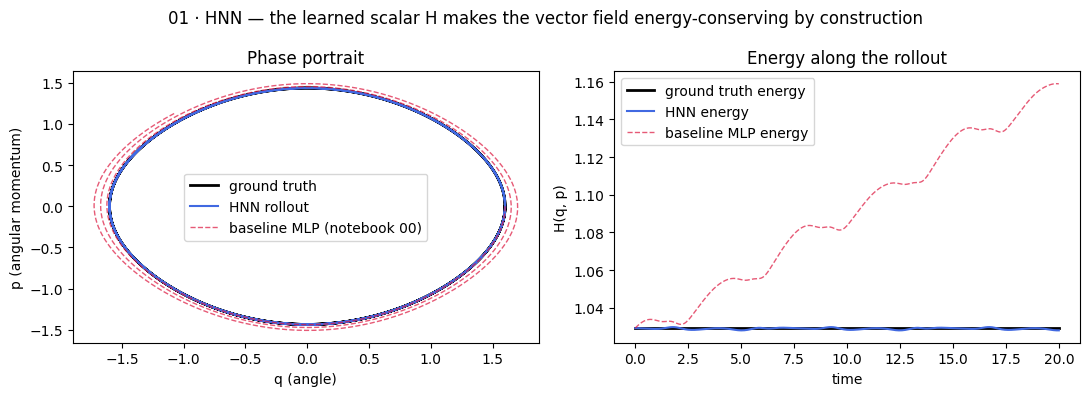

In [6]:
t = np.arange(len(true_traj)) * DT
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(true_traj[:, 0], true_traj[:, 1], label="ground truth", color="black", lw=2)
axes[0].plot(pred_traj[:, 0], pred_traj[:, 1], label="HNN rollout", color="royalblue", lw=1.5)
baseline_path = RESULTS_DIR / "baseline_mlp_pendulum_rollout.npy"
if baseline_path.exists():
    baseline_traj = np.load(baseline_path)
    axes[0].plot(baseline_traj[:, 0], baseline_traj[:, 1], label="baseline MLP (notebook 00)",
                 color="crimson", lw=1, alpha=0.7, linestyle="--")
axes[0].set_xlabel("q (angle)")
axes[0].set_ylabel("p (angular momentum)")
axes[0].set_title("Phase portrait")
axes[0].legend()

axes[1].plot(t, H_true, label="ground truth energy", color="black", lw=2)
axes[1].plot(t, H_pred, label="HNN energy", color="royalblue", lw=1.5)
if baseline_path.exists():
    H_baseline, _, _ = metrics.energy_drift(baseline_traj, systems.pendulum_hamiltonian)
    axes[1].plot(t[:len(H_baseline)], H_baseline, label="baseline MLP energy", color="crimson",
                 lw=1, alpha=0.7, linestyle="--")
axes[1].set_xlabel("time")
axes[1].set_ylabel("H(q, p)")
axes[1].set_title("Energy along the rollout")
axes[1].legend()

fig.suptitle("01 · HNN — the learned scalar H makes the vector field energy-conserving by construction")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_hnn_pendulum.png", dpi=130)
plt.show()

## Step 6 — Save the trained model and metrics

In [7]:
torch.save(hnn.state_dict(), RESULTS_DIR / "hnn_pendulum.pt")

result = {
    "model": "hnn_greydanus2019",
    "system": "pendulum",
    "n_params": models.count_parameters(hnn),
    "final_train_mse": losses[-1],
    "rollout_trajectory_mse": traj_mse,
    "max_abs_energy_drift": float(abs_drift.max()),
    "max_rel_energy_drift": float(rel_drift.max()),
}
with open(RESULTS_DIR / "hnn_pendulum_metrics.json", "w") as f:
    json.dump(result, f, indent=2)
np.save(RESULTS_DIR / "hnn_pendulum_rollout.npy", pred_traj)

if (RESULTS_DIR / "baseline_mlp_pendulum_metrics.json").exists():
    with open(RESULTS_DIR / "baseline_mlp_pendulum_metrics.json") as f:
        baseline_result = json.load(f)
    print(f"\nRelative-energy-drift improvement over baseline: "
          f"{baseline_result['max_rel_energy_drift'] / max(result['max_rel_energy_drift'], 1e-12):.1f}x")

print(json.dumps(result, indent=2))


Relative-energy-drift improvement over baseline: 106.2x
{
  "model": "hnn_greydanus2019",
  "system": "pendulum",
  "n_params": 41001,
  "final_train_mse": 3.3275955502176657e-06,
  "rollout_trajectory_mse": 2.100574576936899e-06,
  "max_abs_energy_drift": 0.0012222644970816265,
  "max_rel_energy_drift": 0.0011875874975852785
}


## Notes for readers coming from a general-ML (non-physics) background

- This is *not* a sequence model: at no point does the network see a trajectory
  during training. It only ever sees isolated `(q, p)` points and is asked to
  predict the instantaneous derivative there — closer to a pointwise regression
  task than to a time-series model. Rollout is a *downstream evaluation procedure*,
  not part of training.
- The "trick" is entirely architectural: constraining the output space of the
  network (a scalar whose gradient defines the field) rather than adding a loss
  penalty for energy conservation. This is why the HNN literature describes this as
  a *hard* inductive bias, as opposed to the *soft* constraint used by
  Physics-Informed Neural Networks (PINNs), which add an energy-conservation
  penalty term to the loss instead.
- `Gruver et al. (2022), "Deconstructing the Inductive Biases of HNN"`
  (`papers/07_Evaluacion_y_Comparativas/`) later showed that part of this
  improvement also comes from modelling the *acceleration* directly rather than
  from the symplectic structure alone — worth keeping in mind before assuming the
  full effect seen here is exclusively about energy conservation.